# Recruiting and retaining drivers is seen by industry watchers as a tough battle for Ola.

Churn among drivers is high and it’s very easy for drivers to stop working for the service on the fly or jump to Uber depending on the rates.

As the companies get bigger, the high churn could become a bigger problem. To find new drivers, Ola is casting a wide net, including people who don’t have cars for jobs. But this acquisition is really costly.

Losing drivers frequently impacts the morale of the organization and acquiring new drivers is more expensive than retaining existing ones.

You are working as a data scientist with the Analytics Department of Ola, focused on driver team attrition. You are provided with the monthly information for a segment of drivers for 2019 and 2020 and tasked to predict whether a driver will be leaving the company or not based on their attributes like:


Why?

Hiring new drivers = 💸 expensive

Losing drivers = 📉 bad for business

Predict whether a driver will leave (attrition) or not”

👉 Isko ML language me:

Binary Classification Problem
0 = Stay
1 = Leave

#overview

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns


In [2]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [3]:
df= pd.read_csv("/content/drive/MyDrive/Aadisingh_B-41/ola_driver.csv")
df.head()

/usr/local/lib/python3.12/dist-packages/google/colab/_dataframe_summarizer.py:88: UserWarning: Could not infer format, so each element will be parsed individually, falling back to `dateutil`. To ensure parsing is consistent and as-expected, please specify a format.
  cast_date_col = pd.to_datetime(column, errors="coerce")


,Unnamed: 0,MMM-YY,Driver_ID,Age,Gender,City,Education_Level,Income,Dateofjoining,LastWorkingDate,Joining Designation,Grade,Total Business Value,Quarterly Rating
0,0,01/01/19,1,28.0,0.0,C23,2,57387,24/12/18,NaN,1,1,2381060,2
1,1,02/01/19,1,28.0,0.0,C23,2,57387,24/12/18,NaN,1,1,-665480,2
2,2,03/01/19,1,28.0,0.0,C23,2,57387,24/12/18,03/11/19,1,1,0,2
3,3,11/01/20,2,31.0,0.0,C7,2,67016,11/06/20,NaN,2,2,0,1
4,4,12/01/20,2,31.0,0.0,C7,2,67016,11/06/20,NaN,2,2,0,1


In [4]:
df.tail()

,Unnamed: 0,MMM-YY,Driver_ID,Age,Gender,City,Education_Level,Income,Dateofjoining,LastWorkingDate,Joining Designation,Grade,Total Business Value,Quarterly Rating
19099,19099,08/01/20,2788,30.0,0.0,C27,2,70254,06/08/20,NaN,2,2,740280,3
19100,19100,09/01/20,2788,30.0,0.0,C27,2,70254,06/08/20,NaN,2,2,448370,3
19101,19101,10/01/20,2788,30.0,0.0,C27,2,70254,06/08/20,NaN,2,2,0,2
19102,19102,11/01/20,2788,30.0,0.0,C27,2,70254,06/08/20,NaN,2,2,200420,2
19103,19103,12/01/20,2788,30.0,0.0,C27,2,70254,06/08/20,NaN,2,2,411480,2


In [5]:
df.shape

(19104, 14)

In [6]:
df.size

267456

In [7]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 19104 entries, 0 to 19103
Data columns (total 14 columns):
 #   Column                Non-Null Count  Dtype  
---  ------                --------------  -----  
 0   Unnamed: 0            19104 non-null  int64  
 1   MMM-YY                19104 non-null  object 
 2   Driver_ID             19104 non-null  int64  
 3   Age                   19043 non-null  float64
 4   Gender                19052 non-null  float64
 5   City                  19104 non-null  object 
 6   Education_Level       19104 non-null  int64  
 7   Income                19104 non-null  int64  
 8   Dateofjoining         19104 non-null  object 
 9   LastWorkingDate       1616 non-null   object 
 10  Joining Designation   19104 non-null  int64  
 11  Grade                 19104 non-null  int64  
 12  Total Business Value  19104 non-null  int64  
 13  Quarterly Rating      19104 non-null  int64  
dtypes: float64(2), int64(8), object(4)
memory usage: 2.0+ MB


In [8]:
df.describe()

,Unnamed: 0,Driver_ID,Age,Gender,Education_Level,Income,Joining Designation,Grade,Total Business Value,Quarterly Rating
count,19104.000000,19104.000000,19043.000000,19052.000000,19104.000000,19104.000000,19104.000000,19104.000000,1.910400e+04,19104.000000
mean,9551.500000,1415.591133,34.668435,0.418749,1.021671,65652.025126,1.690536,2.252670,5.716621e+05,2.008899
std,5514.994107,810.705321,6.257912,0.493367,0.800167,30914.515344,0.836984,1.026512,1.128312e+06,1.009832
min,0.000000,1.000000,21.000000,0.000000,0.000000,10747.000000,1.000000,1.000000,-6.000000e+06,1.000000
25%,4775.750000,710.000000,30.000000,0.000000,0.000000,42383.000000,1.000000,1.000000,0.000000e+00,1.000000
50%,9551.500000,1417.000000,34.000000,0.000000,1.000000,60087.000000,1.000000,2.000000,2.500000e+05,2.000000
75%,14327.250000,2137.000000,39.000000,1.000000,2.000000,83969.000000,2.000000,3.000000,6.997000e+05,3.000000
max,19103.000000,2788.000000,58.000000,1.000000,2.000000,188418.000000,5.000000,5.000000,3.374772e+07,4.000000


In [9]:
df.isnull().sum()

,0
Unnamed: 0,0
MMM-YY,0
Driver_ID,0
Age,61
Gender,52
City,0
Education_Level,0
Income,0
Dateofjoining,0
LastWorkingDate,17488


A small portion of records is missing age (61 cases) and gender (52 cases), which is minimal and can be reasonably estimated without affecting analysis.

A large number of records (17,488) are missing last working date, but this is expected.

In [10]:
df['Age'] = df['Age'].fillna(df['Age'].median())


In [11]:
df['Gender'].value_counts()

,count
Gender,
0.0,11074
1.0,7978


Assume 0 denotes for men and 1 for women

In [12]:
df['Gender']=df['Gender'].fillna(df['Gender'].mode()[0])

If last working date is missing → driver is still working

change null value to current data

In [13]:
df.drop('Unnamed: 0', axis=1, inplace=True)

In [14]:
df.isnull().sum()

,0
MMM-YY,0
Driver_ID,0
Age,0
Gender,0
City,0
Education_Level,0
Income,0
Dateofjoining,0
LastWorkingDate,17488
Joining Designation,0


##Define target (label)
Churn label per row (driver-month): churn = 1 if LastWorkingDate exists and LastWorkingDate ≤ reporting month end; else 0.

#descriptive Analysis

In [15]:
df.describe()

,Driver_ID,Age,Gender,Education_Level,Income,Joining Designation,Grade,Total Business Value,Quarterly Rating
count,19104.000000,19104.000000,19104.000000,19104.000000,19104.000000,19104.000000,19104.000000,1.910400e+04,19104.000000
mean,1415.591133,34.666300,0.417609,1.021671,65652.025126,1.690536,2.252670,5.716621e+05,2.008899
std,810.705321,6.248026,0.493178,0.800167,30914.515344,0.836984,1.026512,1.128312e+06,1.009832
min,1.000000,21.000000,0.000000,0.000000,10747.000000,1.000000,1.000000,-6.000000e+06,1.000000
25%,710.000000,30.000000,0.000000,0.000000,42383.000000,1.000000,1.000000,0.000000e+00,1.000000
50%,1417.000000,34.000000,0.000000,1.000000,60087.000000,1.000000,2.000000,2.500000e+05,2.000000
75%,2137.000000,39.000000,1.000000,2.000000,83969.000000,2.000000,3.000000,6.997000e+05,3.000000
max,2788.000000,58.000000,1.000000,2.000000,188418.000000,5.000000,5.000000,3.374772e+07,4.000000


lets check how many drivers are exists


In [16]:
df['Driver_ID'].value_counts()


,count
Driver_ID,
2784,24
2753,24
2771,24
1745,24
2766,24
...,...
136,1
138,1
2710,1


Drivers with higher counts are more active and contributing more to operations

count of unique drivers !

In [17]:
unique_drivers=df['Driver_ID'].unique()
print(len(unique_drivers))


2381


In [18]:
df['Driver_ID'].value_counts().count()

np.int64(2381)

👉 value_counts() gives frequency

👉 .count() gives number of unique IDs

##temporal Analysis

How many drivers joined and left each month?

In [19]:
df['Dateofjoining'].head()

,Dateofjoining
0,24/12/18
1,24/12/18
2,24/12/18
3,11/06/20
4,11/06/20


In [20]:
print(df['LastWorkingDate'].dtype)

object


In [21]:
df['Dateofjoining'] = pd.to_datetime(df['Dateofjoining'],format='%d-%m-%Y', errors='coerce')
df['LastWorkingDate'] = pd.to_datetime(df['LastWorkingDate'],format='%d-%m-%Y', errors='coerce')

In [22]:
print(df.columns)
print(df.dtypes)


Index(['MMM-YY', 'Driver_ID', 'Age', 'Gender', 'City', 'Education_Level',
       'Income', 'Dateofjoining', 'LastWorkingDate', 'Joining Designation',
       'Grade', 'Total Business Value', 'Quarterly Rating'],
      dtype='object')
MMM-YY                          object
Driver_ID                        int64
Age                            float64
Gender                         float64
City                            object
Education_Level                  int64
Income                           int64
Dateofjoining           datetime64[ns]
LastWorkingDate         datetime64[ns]
Joining Designation              int64
Grade                            int64
Total Business Value             int64
Quarterly Rating                 int64
dtype: object


why dont use count here ?


🔹 3. .fillna(0)
Replaces missing values (NaN) with 0

 we determine the average tenure of drivers in the dataset?

#feature Engineering

Feature engineering means:

Creating, modifying, or selecting variables (features) from raw data so that models can learn better patterns.

🔹 Why is it Important?

Improves model accuracy 📈
Helps models learn faster ⚡
Reduces overfitting
Makes data more meaningful

In [23]:
df=pd.read_csv("/content/drive/MyDrive/Aadisingh_B-41/ola_driver.csv")
df.head()

/usr/local/lib/python3.12/dist-packages/google/colab/_dataframe_summarizer.py:88: UserWarning: Could not infer format, so each element will be parsed individually, falling back to `dateutil`. To ensure parsing is consistent and as-expected, please specify a format.
  cast_date_col = pd.to_datetime(column, errors="coerce")


,Unnamed: 0,MMM-YY,Driver_ID,Age,Gender,City,Education_Level,Income,Dateofjoining,LastWorkingDate,Joining Designation,Grade,Total Business Value,Quarterly Rating
0,0,01/01/19,1,28.0,0.0,C23,2,57387,24/12/18,NaN,1,1,2381060,2
1,1,02/01/19,1,28.0,0.0,C23,2,57387,24/12/18,NaN,1,1,-665480,2
2,2,03/01/19,1,28.0,0.0,C23,2,57387,24/12/18,03/11/19,1,1,0,2
3,3,11/01/20,2,31.0,0.0,C7,2,67016,11/06/20,NaN,2,2,0,1
4,4,12/01/20,2,31.0,0.0,C7,2,67016,11/06/20,NaN,2,2,0,1


Target variable is LastWorkingDays

now a question is how many drivers are still working and how many are left !

create a column name still_drivers with assumtion

1-> left
0-> active

shows in df['churn'] column

# Eda

In [24]:
# Summary stats
print(df[['Age', 'Income', 'Total Business Value']].describe())

                Age         Income  Total Business Value
count  19043.000000   19104.000000          1.910400e+04
mean      34.668435   65652.025126          5.716621e+05
std        6.257912   30914.515344          1.128312e+06
min       21.000000   10747.000000         -6.000000e+06
25%       30.000000   42383.000000          0.000000e+00
50%       34.000000   60087.000000          2.500000e+05
75%       39.000000   83969.000000          6.997000e+05
max       58.000000  188418.000000          3.374772e+07


<Axes: >

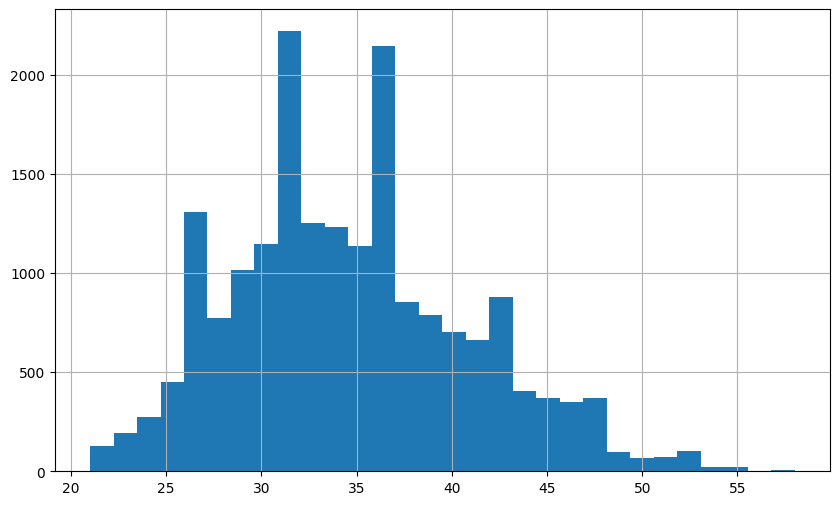

In [25]:
df['Age'].hist(bins=30,figsize=(10,6))

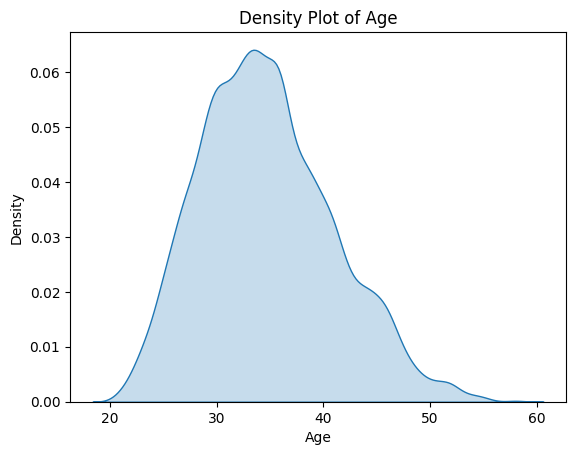

In [26]:
sns.kdeplot(df['Age'], fill=True)

plt.title("Density Plot of Age")
plt.xlabel("Age")
plt.ylabel("Density")
plt.show()

The highest peaks are observed at 32 and 37 years.

This suggests that the dataset is dominated by mid-age working individuals, especially those in their early to mid-30s.

Since the distribution is slightly skewed, it indicates that:
There are fewer people in the younger and older age groups compared to the middle-age group.


<Axes: >

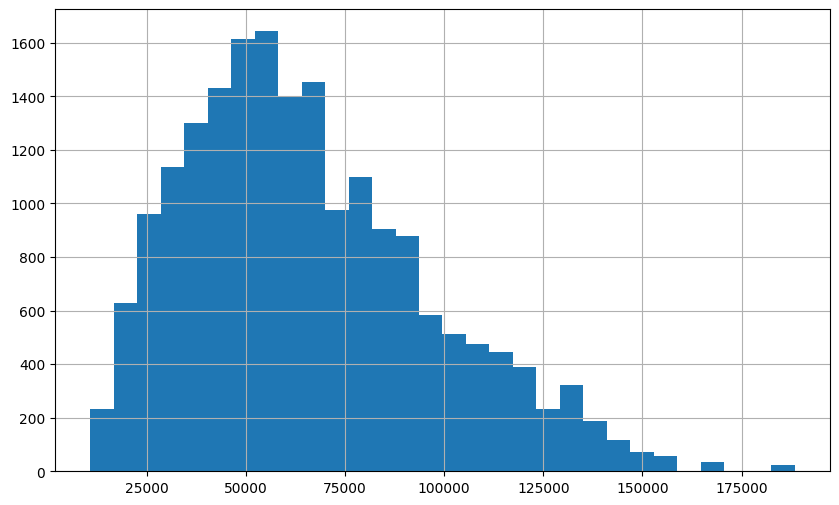

In [27]:
df['Income'].hist(bins=30,figsize=(10,6))

The majority of incomes lie between ₹40,000 to ₹65,000, indicating that most individuals fall in the mid-income group.

The distribution has a long tail on the right side, which shows the presence of few high-income individuals.

## to detect outliers

In [28]:
df['Income'].describe()

,Income
count,19104.000000
mean,65652.025126
std,30914.515344
min,10747.000000
25%,42383.000000
50%,60087.000000
75%,83969.000000
max,188418.000000


IQR

In [29]:
in_25=np.percentile(df['Income'],25)
print(in_25)

42383.0


 “Around 25% of the customers earn ₹42,383 or less. This represents the lower-income segment of the population, while the remaining 75% earn above this level

In [30]:
in_50=np.percentile(df['Income'],50)
print(in_50)

60087.0


“Around 50% of the customers earn ₹60,087 or less.

In [31]:
in_75=np.percentile(df['Income'],75)
print(in_75)

83969.0


“Around 75% of the customers earn ₹83,969 or less.

In [32]:
iqr_income=in_75-in_25
print(iqr_income)

41586.0


In [33]:
normal_range=(df['Income'].max() - df['Income'].min())
print(normal_range)

177671


The Interquartile Range (IQR) of income is ₹41,586.

This means that the middle 50% of the population’s income lies within a range of ₹41,586.

The normal range of income (Maximum − Minimum) is ₹177,671.

This shows that the overall income distribution is highly spread out, covering both very low and very high-income individuals.

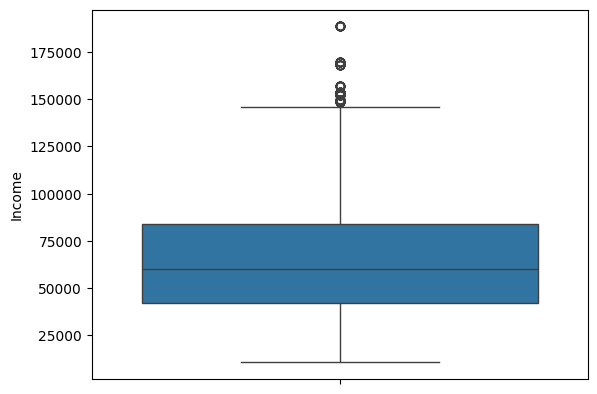

In [34]:
sns.boxplot(df['Income'])
plt.show()

In [35]:
 # upper limit = Q3 + 1.5 * IQR

upper = 83969 + 1.5*(iqr_income)
print(upper)

146348.0


In [36]:
# all the values greater than upper bound are outliers
outliers_income = df[df["Income"] > upper]

# number of outliers
len(outliers_income)

188

In [37]:
(188/19104)*100

0.9840871021775545

this indicates that less than 1% of the population behaves significantly differently from the majority.

🔹 Key business insights:
The dataset is highly stable and mostly consistent
Only a very small segment of customers shows extreme behavior
These extreme values may represent:
High-value premium customers (in income case)
Or unusual/rare cases in the business

These outliers represent premium/high-value customers

<Axes: >

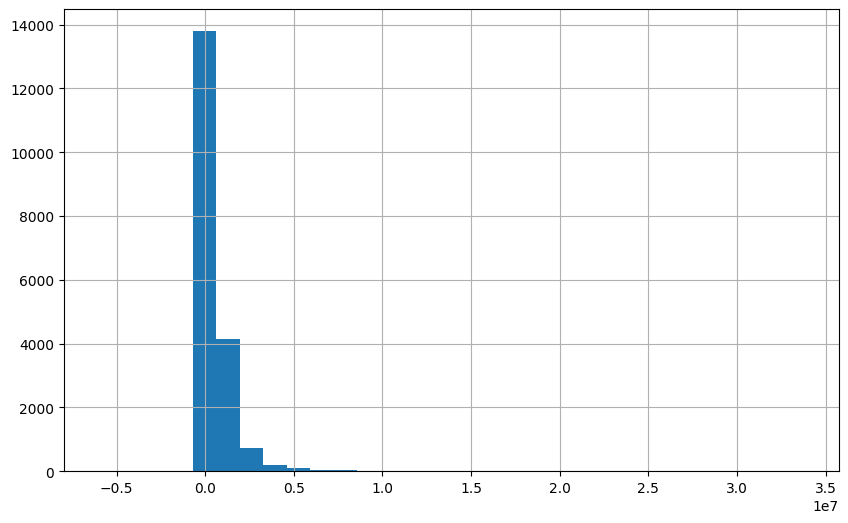

In [38]:
df['Total Business Value'].hist(bins=30,figsize=(10,6))

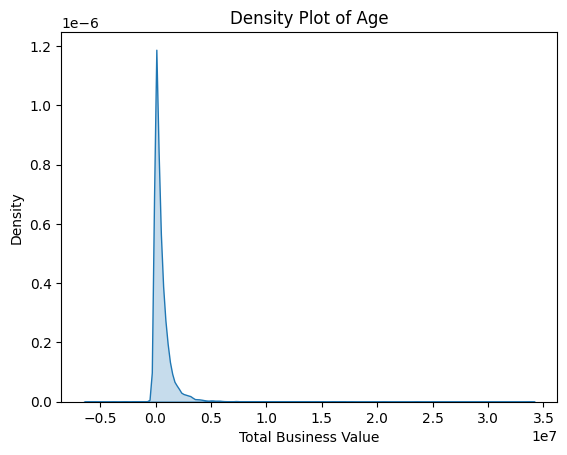

In [39]:
sns.kdeplot(df['Total Business Value'], fill=True)

plt.title("Density Plot of Age")
plt.xlabel("Total Business Value")
plt.ylabel("Density")
plt.show()

Heavy skew (most values near 0)
📌 Very high positive + some negative value

**use IQR Technique for total business value**

In [40]:
Total_25=np.percentile(df['Total Business Value'],25)
print(Total_25)

0.0


25% of your employees  records have:

Zero Total Business Value

In [41]:
Total_50=np.percentile(df['Total Business Value'],50)
print(Total_50)

250000.0


50% of your data points generate ≤ 250,000 value
This represents your “middle-performing segment”

In [42]:
Total_75=np.percentile(df['Total Business Value'],75)
print(Total_75)

699700.0


Top 25% of records generate more than 699,700 value
These are your high-value contributors

In [43]:
iqr_totalBusinessValue=Total_75-Total_25
print(iqr_totalBusinessValue)

699700.0


In [44]:
normal_rangeOftotal=(df['Total Business Value'].max() - df['Total Business Value'].min())
print(normal_range)

177671


There is huge variability in performance
Some generate almost nothing (Q1 = 0)
Some generate very high value (Q3 ~ 700K)

👉 Conclusion:

 business is highly uneven and skewed — not stable or uniform

In [45]:
# df['Total Business Value'].max()
df['Total Business Value'].min()

-6000000

range>=Q3

In [46]:
upper_total=699700+1.5*(iqr_totalBusinessValue)
print(upper_total)

1749250.0


In [47]:
outliers_TotalBusinessValue = df[df["Total Business Value"] > upper_total]

# number of outliers
len(outliers_TotalBusinessValue)

1355

In [48]:
(1355/19104)*100

7.092755443886096

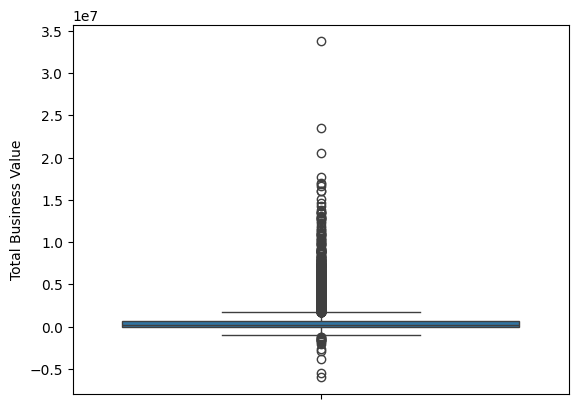

In [49]:
sns.boxplot(df['Total Business Value'])
plt.show()

The Total Business Value distribution is extremely skewed, with most observations clustered near zero and a few extreme high-value contributors. This indicates a strong dependency on a small group of high performers, following a Pareto-like distribution. The presence of negative values suggests possible losses, refunds, or data inconsistencies that require validation. Overall, the business is not failing, but highly concentrated and vulnerable to top-performer dependency, making segmentation and retention strategies critica

## How does Quarterly Rating vary across different drivers and time periods?


In [50]:
drivers_rating=df['Driver_ID'].groupby(df['Quarterly Rating']).count().reset_index()
print(drivers_rating)

   Quarterly Rating  Driver_ID
0                 1       7679
1                 2       5553
2                 3       3895
3                 4       1977


In [51]:
df['Dateofjoining'] = pd.to_datetime(df['Dateofjoining'], format='%d/%m/%y')
df['Quarter']=df['Dateofjoining'].dt.to_period('Q')
print(df['Quarter'])

0        2018Q4
1        2018Q4
2        2018Q4
3        2020Q2
4        2020Q2
          ...  
19099    2020Q3
19100    2020Q3
19101    2020Q3
19102    2020Q3
19103    2020Q3
Name: Quarter, Length: 19104, dtype: period[Q-DEC]


Q1 → Jan, Feb, Mar
Q2 → Apr, May, Jun
Q3 → Jul, Aug, Sep
Q4 → Oct, Nov, Dec

In [52]:
quarter_rating = df.groupby('Quarter')['Quarterly Rating'].mean().reset_index()
print(quarter_rating)
df['Quarter'] = df['Quarter'].astype(str)

   Quarter  Quarterly Rating
0   2013Q1          2.169118
1   2013Q2          2.273381
2   2013Q3          2.456376
3   2013Q4          1.907063
4   2014Q1          2.636364
5   2014Q2          2.239130
6   2014Q3          2.540107
7   2014Q4          2.356784
8   2015Q1          2.222222
9   2015Q2          2.278618
10  2015Q3          2.436722
11  2015Q4          2.535533
12  2016Q1          2.278515
13  2016Q2          2.489117
14  2016Q3          2.493392
15  2016Q4          2.208333
16  2017Q1          2.103448
17  2017Q2          2.277778
18  2017Q3          2.200000
19  2017Q4          2.468582
20  2018Q1          2.205318
21  2018Q2          2.265636
22  2018Q3          2.360502
23  2018Q4          2.008864
24  2019Q1          1.648496
25  2019Q2          1.734534
26  2019Q3          1.679619
27  2019Q4          1.694486
28  2020Q1          1.554737
29  2020Q2          1.651888
30  2020Q3          1.490157
31  2020Q4          1.262940


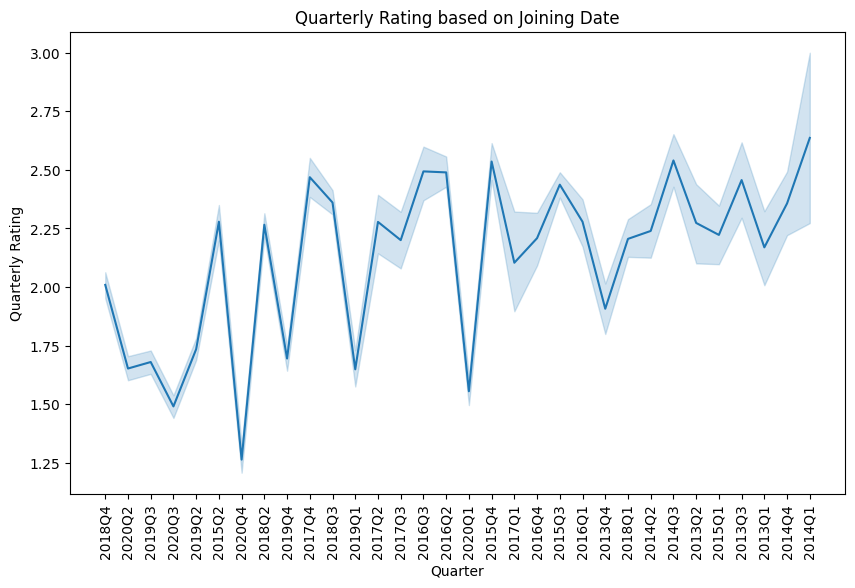

In [53]:
plt.figure(figsize=(10,6))
sns.lineplot(data=df, x='Quarter', y='Quarterly Rating')
plt.xticks(rotation=90)
plt.title("Quarterly Rating based on Joining Date")
plt.show()

o Are there any trends or patterns in the monthly income or business value
acquired?

In [54]:
df['Income'].describe()

,Income
count,19104.000000
mean,65652.025126
std,30914.515344
min,10747.000000
25%,42383.000000
50%,60087.000000
75%,83969.000000
max,188418.000000


Assuming Income represents monthly earnings based on realistic salary ranges…

 The income distribution is right-skewed, indicating that most individuals earn moderate monthly income, while a small number of individuals earn significantly higher amounts.

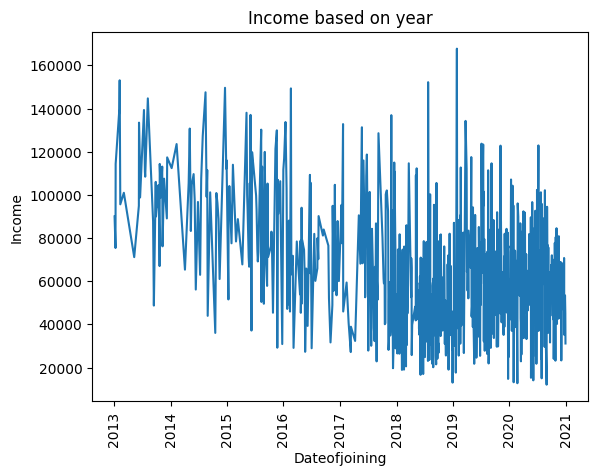

In [55]:
Income=df['Income'].groupby(df['Dateofjoining']).mean()
sns.lineplot(data=Income)
plt.xticks(rotation=90)
plt.title("Income based on year")
plt.show()

The average yearly income shows a gradual declining trend over time.

In [56]:
df['Join_Year'] = pd.to_datetime(df['Dateofjoining']).dt.year

df['Income'].groupby(df['Join_Year']).mean()

,Income
Join_Year,
2013,104466.467532
2014,96026.733002
2015,84773.602036
2016,71145.622769
2017,66612.708182
2018,54937.635130
2019,60659.958804
2020,60921.538315


Older joiners earning more:

“Drivers who joined earlier tend to have higher income, possibly due to experience or tenure benefits.”

New joiners earning less:

“Recently joined drivers have lower income, indicating a ramp-up period.”

In [57]:
df['Dateofjoining'] = pd.to_datetime(df['Dateofjoining'], errors='coerce').dt.normalize()
df['LastWorkingDate'] = pd.to_datetime(df['LastWorkingDate'], errors='coerce').dt.normalize()

joins = df.groupby(df['Dateofjoining'].dt.to_period('M')).size()
leave = df.groupby(df['LastWorkingDate'].dt.to_period('M')).size()

# Align the series to ensure that months with no joins/leaves are handled correctly
all_months = pd.period_range(start=min(joins.index.min(), leave.index.min()),
                            end=max(joins.index.max(), leave.index.max()), freq='M')
joins = joins.reindex(all_months, fill_value=0)
leave = leave.reindex(all_months, fill_value=0)

summary = pd.DataFrame({
    'Joined': joins,
    'Left': leave
}).fillna(0)

summary.head()

/tmp/ipykernel_4773/1324767914.py:2: UserWarning: Could not infer format, so each element will be parsed individually, falling back to `dateutil`. To ensure parsing is consistent and as-expected, please specify a format.
  df['LastWorkingDate'] = pd.to_datetime(df['LastWorkingDate'], errors='coerce').dt.normalize()


,Joined,Left
2013-01,62,0
2013-02,50,0
2013-03,24,0
2013-04,0,0
2013-05,32,0


In [58]:
summary['year']=summary.index.to_timestamp().year

In [59]:
yearly_summary = summary.groupby('year').sum()

print(yearly_summary)

      Joined  Left
year              
2013     693     0
2014     603     0
2015    1965     0
2016    1625     0
2017    1100     0
2018    4936     5
2019    4515   825
2020    3667   786


Higher churn is observed among recently joined drivers…

Statistical test (strong proof) later


In [60]:
df['Total Business Value'].describe()

,Total Business Value
count,1.910400e+04
mean,5.716621e+05
std,1.128312e+06
min,-6.000000e+06
25%,0.000000e+00
50%,2.500000e+05
75%,6.997000e+05
max,3.374772e+07


In [61]:
df.groupby('Join_Year')['Total Business Value'].mean()

,Total Business Value
Join_Year,
2013,1.213787e+06
2014,1.128657e+06
2015,8.864929e+05
2016,7.855546e+05
2017,7.454556e+05
2018,5.636233e+05
2019,4.176330e+05
2020,2.435653e+05


In the initial years, the organization had a smaller workforce, resulting in lower total business revenue.

As hiring increased over time, the growing workforce contributed to a steady rise in total business value.

The business reached its peak performance around 2015–2018, coinciding with the highest level of employee hiring and workforce expansion.
After this peak period, a gradual increase in employee attrition was observed, particularly among newly hired drivers.

The rising attrition negatively impacted workforce stability and reduced overall productivity.

As a result, the total business value began to decline in the later years, indicating potential challenges in employee retention and operational efficiency.

##
How should missing values in LastWorkingDate be treated, considering it
indicates whether a driver has left?


In [62]:
df['Churn'] = df['LastWorkingDate'].notna().astype(int)
df[['Churn','LastWorkingDate']].head()

,Churn,LastWorkingDate
0,0,NaT
1,0,NaT
2,1,2019-03-11
3,0,NaT
4,0,NaT


📌 Final result
1 = Driver has left (churned)
0 = Driver is still active

the LastWorkingDate column, where values are missing, we can treat them as ‘Still Working’. Since the data type is object, we are converting it into a datetime format and filling the missing values with today’s date

#Correlation and Relationships:



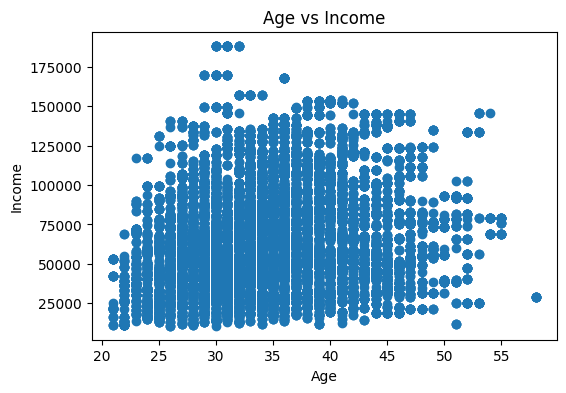

In [63]:

plt.figure(figsize=(6,4))
plt.scatter(df['Age'], df['Income'])
plt.xlabel('Age')
plt.ylabel('Income')
plt.title('Age vs Income')
plt.show()


👉 Conclusion:
Weak positive correlation

In [64]:
corr = df['Age'].corr(df['Income'])
print(corr)

0.19111177421789227


No age bias in hiring

Young drivers can perform as well as experienced ones
Hiring should focus on skills, not age

Income variability = performance-driven system
Incentives, effort, and efficiency likely impact earnings more

## How do Education_Level and City affect Total Business Value

Since both features are categorical, we DON’T use correlation directly.

In [65]:
df.groupby('Education_Level')['Total Business Value'].mean()

,Total Business Value
Education_Level,
0,565410.657872
1,601287.867133
2,545364.175755


In [66]:
df['Total Business Value'].groupby(df['City']).mean().sort_values(ascending=False)

,Total Business Value
City,
C13,796263.075571
C29,736637.511111
C12,667282.310867
C26,661837.445339
C5,634855.975610
C16,632585.712271
C19,630978.151986
C14,607931.635802
C28,591406.778917


In [67]:

pd.set_option('display.float_format', '{:.2f}'.format)

In [68]:
df.groupby(['City', 'Education_Level'])['Total Business Value'].mean().sort_values(ascending=False)

City  Education_Level
C13   1                 1037106.39
      0                  907502.60
C12   0                  865403.03
C29   0                  854741.25
C26   0                  784708.12
                           ...    
C14   1                  231839.50
C17   2                  225343.46
C11   0                  206695.29
C23   0                  201321.55
C9    0                  158471.67
Name: Total Business Value, Length: 87, dtype: float64

Which education level performs best in each city

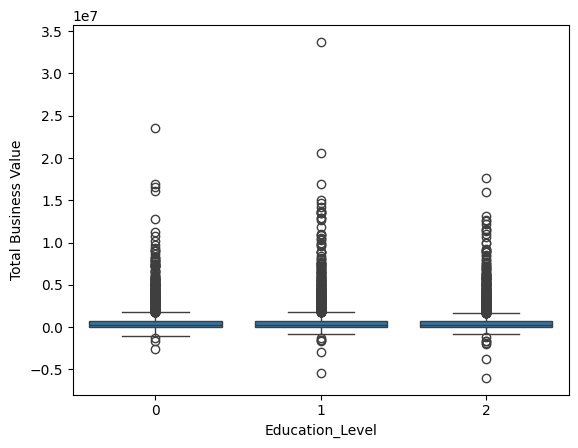

In [69]:
sns.boxplot(x='Education_Level', y='Total Business Value', data=df)
plt.show()

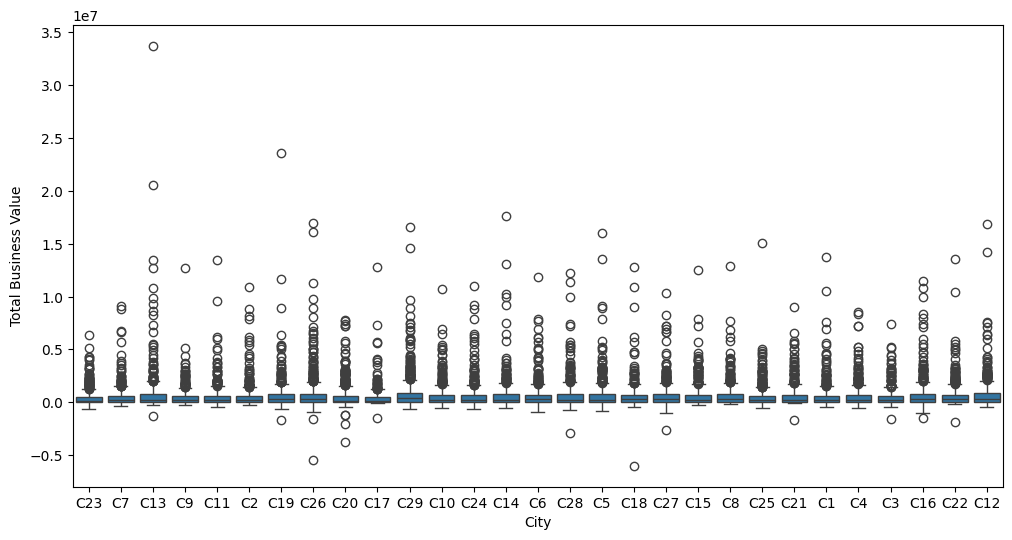

In [70]:
plt.figure(figsize=(12,6))
sns.boxplot(x='City', y='Total Business Value', data=df)
plt.show()

“What is the average business value for each City + Education Level combination?”

In [71]:
top_cities = df['City'].value_counts().index[:5]
df_small = df[df['City'].isin(top_cities)]

<Axes: xlabel='Education_Level', ylabel='City'>

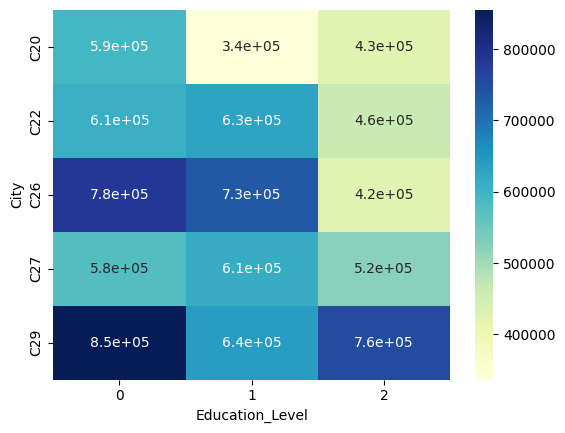

In [72]:
pivot = df_small.pivot_table(
    values='Total Business Value',
    index='City',
    columns='Education_Level',
    aggfunc='mean'
)

sns.heatmap(pivot, annot=True, cmap='YlGnBu')

##o Are drivers with higher Quarterly Rating more likely to stay longer?

In [73]:
df['LastWorkingDate']=df['LastWorkingDate'].fillna(pd.to_datetime('today'))

In [74]:
df['Tenure'] = (df['LastWorkingDate'] - df['Dateofjoining']).dt.days

In [75]:
df.groupby('Quarterly Rating')['Tenure'].mean()

,Tenure
Quarterly Rating,
1,2201.99
2,3018.80
3,3187.85
4,3025.08


In [76]:
df.groupby('Quarterly Rating')['Churn'].mean()

,Churn
Quarterly Rating,
1,0.19
2,0.03
3,0.01
4,0.01


In [77]:
df[['Quarterly Rating', 'Tenure']].corr()

,Quarterly Rating,Tenure
Quarterly Rating,1.00,0.36
Tenure,0.36,1.00


In [78]:
df[['Quarterly Rating', 'Churn']].corr()

,Quarterly Rating,Churn
Quarterly Rating,1.00,-0.26
Churn,-0.26,1.00


<Axes: xlabel='Quarterly Rating', ylabel='Tenure'>

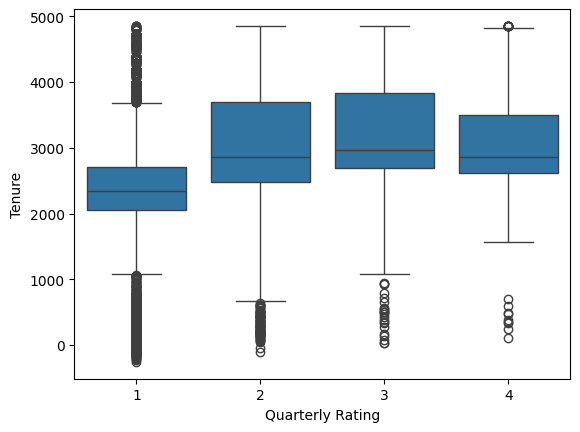

In [79]:
sns.boxplot(x='Quarterly Rating', y='Tenure', data=df)

In [80]:
df.head()

,Unnamed: 0,MMM-YY,Driver_ID,Age,Gender,City,Education_Level,Income,Dateofjoining,LastWorkingDate,Joining Designation,Grade,Total Business Value,Quarterly Rating,Quarter,Join_Year,Churn,Tenure
0,0,01/01/19,1,28.00,0.00,C23,2,57387,2018-12-24,2026-04-20 14:57:27.299829,1,1,2381060,2,2018Q4,2018,0,2674
1,1,02/01/19,1,28.00,0.00,C23,2,57387,2018-12-24,2026-04-20 14:57:27.299829,1,1,-665480,2,2018Q4,2018,0,2674
2,2,03/01/19,1,28.00,0.00,C23,2,57387,2018-12-24,2019-03-11 00:00:00.000000,1,1,0,2,2018Q4,2018,1,77
3,3,11/01/20,2,31.00,0.00,C7,2,67016,2020-06-11,2026-04-20 14:57:27.299829,2,2,0,1,2020Q2,2020,0,2139
4,4,12/01/20,2,31.00,0.00,C7,2,67016,2020-06-11,2026-04-20 14:57:27.299829,2,2,0,1,2020Q2,2020,0,2139


In [81]:
# Target column (sirf ek column)
y = df['Churn']

# Baaki saare columns (Churn hata ke)
X = df.drop('Churn', axis=1)

In [82]:
print(X.shape)
print(y.shape)

(19104, 17)
(19104,)


In [83]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

In [84]:
from sklearn.preprocessing import StandardScaler
from sklearn.impute import SimpleImputer

scaler = StandardScaler()
imputer = SimpleImputer(strategy='median')

# Adding 'Tenure' to the drop list to prevent data leakage
columns_to_drop = ['Unnamed: 0', 'MMM-YY', 'City', 'Dateofjoining', 'LastWorkingDate', 'Quarter', 'Tenure']

X_train_numeric = X_train.drop(columns=columns_to_drop, errors='ignore')
X_test_numeric = X_test.drop(columns=columns_to_drop, errors='ignore')

# Impute any remaining NaNs before scaling
X_train_imputed = imputer.fit_transform(X_train_numeric)
X_test_imputed = imputer.transform(X_test_numeric)

X_train_scaled = scaler.fit_transform(X_train_imputed)
X_test_scaled = scaler.transform(X_test_imputed)

In [85]:
from sklearn.linear_model import LogisticRegression

# Re-initializing and fitting the model on the updated scaled data
model = LogisticRegression(class_weight='balanced', max_iter=1000)
model.fit(X_train_scaled, y_train)

LogisticRegression(class_weight='balanced', max_iter=1000)

Updated Accuracy Score: 0.6786181627846114

Updated Classification Report:
              precision    recall  f1-score   support

           0       0.98      0.66      0.79      3498
           1       0.19      0.88      0.32       323

    accuracy                           0.68      3821
   macro avg       0.59      0.77      0.55      3821
weighted avg       0.92      0.68      0.75      3821



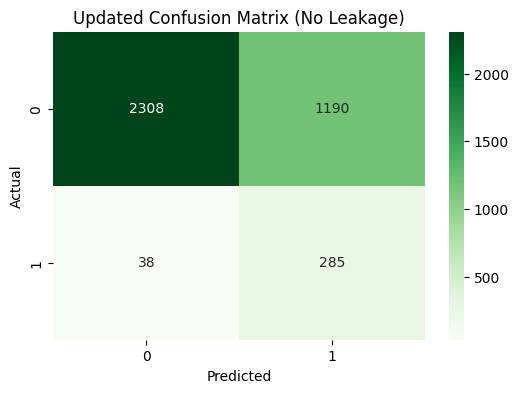

In [88]:
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix


# Re-evaluating the model after fixing data leakage
y_pred = model.predict(X_test_scaled)

print('Updated Accuracy Score:', accuracy_score(y_test, y_pred))
print('\nUpdated Classification Report:')
print(classification_report(y_test, y_pred))

# Plot Updated Confusion Matrix
plt.figure(figsize=(6,4))
sns.heatmap(confusion_matrix(y_test, y_pred), annot=True, fmt='d', cmap='Greens')
plt.title('Updated Confusion Matrix (No Leakage)')
plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.show()

### Model Evaluation
Now we evaluate the performance of our Logistic Regression model using the test data.

# Advanced Driver-Level Modeling
We will now aggregate the data per driver and create features that capture their performance trends.

Advanced Model Accuracy: 0.8071278825995807

Classification Report:
              precision    recall  f1-score   support

           0       0.76      0.58      0.66       153
           1       0.82      0.91      0.87       324

    accuracy                           0.81       477
   macro avg       0.79      0.75      0.76       477
weighted avg       0.80      0.81      0.80       477



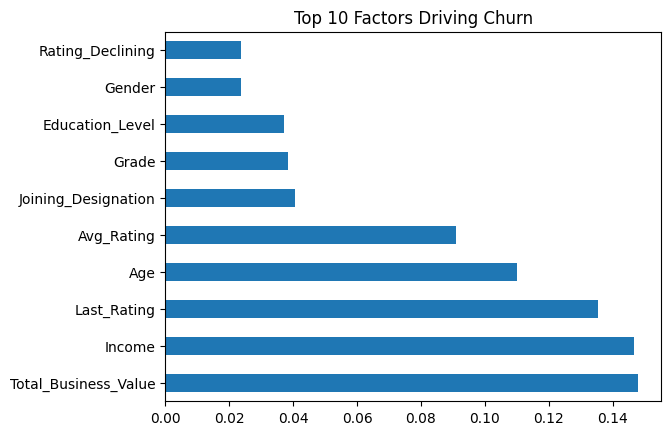

In [89]:
import pandas as pd
import numpy as np
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import classification_report, confusion_matrix, accuracy_score
from sklearn.model_selection import train_test_split

# 1. Feature Aggregation per Driver
# We take the maximum/last value for static features and average/sum for dynamic ones
driver_agg = df.groupby('Driver_ID').agg({
    'Age': 'max',
    'Gender': 'first',
    'City': 'first',
    'Education_Level': 'last',
    'Income': 'last',
    'Joining Designation': 'last',
    'Grade': 'last',
    'Total Business Value': 'sum',
    'Quarterly Rating': ['last', 'mean'],
    'Churn': 'max'  # 1 if they ever churned, else 0
})

# Flatten multi-index columns
driver_agg.columns = ['Age', 'Gender', 'City', 'Education_Level', 'Income',
                      'Joining_Designation', 'Grade', 'Total_Business_Value',
                      'Last_Rating', 'Avg_Rating', 'Churn']

# 2. Feature Engineering: Rating Trend
# If last rating < average rating, the driver's performance is declining
driver_agg['Rating_Declining'] = (driver_agg['Last_Rating'] < driver_agg['Avg_Rating']).astype(int)

# 3. Categorical Encoding for City
driver_agg = pd.get_dummies(driver_agg, columns=['City'], drop_first=True)

# 4. Prepare for Training
X_advanced = driver_agg.drop('Churn', axis=1)
y_advanced = driver_agg['Churn']

X_train_adv, X_test_adv, y_train_adv, y_test_adv = train_test_split(
    X_advanced, y_advanced, test_size=0.2, random_state=42, stratify=y_advanced
)

# 5. Random Forest Model
rf_model = RandomForestClassifier(n_estimators=100, class_weight='balanced', random_state=42)
rf_model.fit(X_train_adv, y_train_adv)

# 6. Evaluation
y_pred_adv = rf_model.predict(X_test_adv)
print('Advanced Model Accuracy:', accuracy_score(y_test_adv, y_pred_adv))
print('\nClassification Report:')
print(classification_report(y_test_adv, y_pred_adv))

# Feature Importance Visualization
importances = pd.Series(rf_model.feature_importances_, index=X_advanced.columns)
importances.nlargest(10).plot(kind='barh')
plt.title('Top 10 Factors Driving Churn')
plt.show()

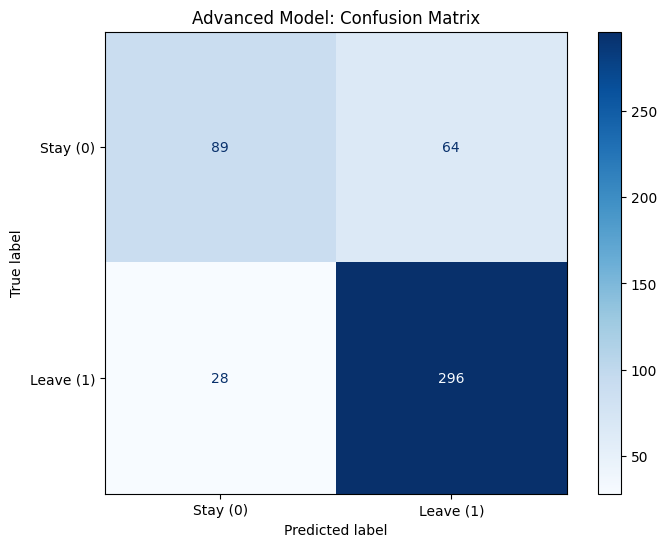

Accuracy: 80.71%


In [90]:
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay

# Predicting on the advanced test set
y_pred_adv = rf_model.predict(X_test_adv)

# Displaying the Confusion Matrix
cm = confusion_matrix(y_test_adv, y_pred_adv)
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=['Stay (0)', 'Leave (1)'])

fig, ax = plt.subplots(figsize=(8, 6))
disp.plot(ax=ax, cmap='Blues')
plt.title('Advanced Model: Confusion Matrix')
plt.show()

# Final Summary Metrics
print(f"Accuracy: {accuracy_score(y_test_adv, y_pred_adv):.2%}")

### Analysis of Improvements
*   **Driver-Level:** By aggregating, we removed the bias of long-tenure drivers appearing more often in the training set.
*   **Trend Feature:** `Rating_Declining` captures behavioral shifts that a monthly snapshot cannot.
*   **Random Forest:** This model can now show us exactly which features (like `Total_Business_Value` or `Avg_Rating`) are the biggest predictors of churn.